In [ ]:
# Paso 1: Importar la librería Pandas y crear el DataFrame
import pandas as pd
import numpy as np # Numpy ayuda a manejar valores numéricos
import matplotlib.pyplot as plt
import seaborn as sns

# importar el dataset
df_empleados = pd.read_csv('/content/RR_HH.csv')
print("DataFrame original 'sucio':")
df_empleados

# Paso 2: Diagnóstico
print("--- Información General del DataFrame ---")
df_empleados.info()

print("\n--- Resumen Estadístico (solo columnas numéricas) ---")
print(df_empleados.describe())

print("\n--- Conteo de Valores Nulos por Columna ---")
print(df_empleados.isnull().sum())

# imprimir primeras filas
df_empleados.head()

DataFrame original 'sucio':
--- Información General del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   NOMBRE           14 non-null     object 
 1   DNI              15 non-null     object 
 2   AREA             13 non-null     object 
 3   PUESTO           13 non-null     object 
 4   REMUNERACION     13 non-null     float64
 5   COMIDA_FAVORITA  14 non-null     object 
dtypes: float64(1), object(5)
memory usage: 852.0+ bytes

--- Resumen Estadístico (solo columnas numéricas) ---
       REMUNERACION
count  1.300000e+01
mean   1.078846e+06
std    2.534344e+06
min    2.500000e+04
25%    3.300000e+05
50%    3.800000e+05
75%    4.500000e+05
max    9.500000e+06

--- Conteo de Valores Nulos por Columna ---
NOMBRE             1
DNI                0
AREA               2
PUESTO             2
REMUNERACION       2
COMIDA_FAVORITA   

,NOMBRE,DNI,AREA,PUESTO,REMUNERACION,COMIDA_FAVORITA
0,Ana Gómez,35.123.456,Ventas,Vendedor Sr.,450000.0,Pizza
1,Carlos Diaz,38.789.123,Tecnología,Desarrollador Jr.,380000.0,Milanesa
2,Carlos Diaz,38.789.123,Tecnología,Desarrollador Jr.,380000.0,Milanesa
3,Laura Fernandez,40.456.789,Marketing,NaN,320000.0,Tarta
4,Pedro Martinez,33.987.654,NaN,Analista de Datos,510000.0,Asado


In [ ]:
#Paso 3: Eliminar la columna irrelevante 'COMIDA_FAVORITA'
df_empleados_limpio = df_empleados.drop(columns=['COMIDA_FAVORITA'])
print("DataFrame sin la columna irrelevante:")
df_empleados_limpio.head()

DataFrame sin la columna irrelevante:


,NOMBRE,DNI,AREA,PUESTO,REMUNERACION
0,Ana Gómez,35.123.456,Ventas,Vendedor Sr.,450000.0
1,Carlos Diaz,38.789.123,Tecnología,Desarrollador Jr.,380000.0
2,Carlos Diaz,38.789.123,Tecnología,Desarrollador Jr.,380000.0
3,Laura Fernandez,40.456.789,Marketing,NaN,320000.0
4,Pedro Martinez,33.987.654,NaN,Analista de Datos,510000.0


In [ ]:
# 3.2. Manejo de Duplicados
# Contamos cuántas filas duplicadas hay

print(f"Número de filas duplicadas: {df_empleados_limpio.duplicated().sum()}")
#print(f"Número de filas duplicadas: {df_empleados_limpio.duplicated(subset=["DNI"]).sum()}")

filas_duplicadas = df_empleados_limpio[df_empleados_limpio.duplicated()]
#filas_duplicadas = df_empleados_limpio[df_empleados_limpio.duplicated(subset=["DNI"])]
print("Filas duplicadas:")
print(filas_duplicadas)

Número de filas duplicadas: 2
Filas duplicadas:
             NOMBRE         DNI        AREA             PUESTO  REMUNERACION
2       Carlos Diaz  38.789.123  Tecnología  Desarrollador Jr.      380000.0
9  Valentina Torres  42.333.444        RRHH   Analista de RRHH      390000.0


In [ ]:
# Eliminamos las filas duplicadas
df_empleados_limpio = df_empleados_limpio.drop_duplicates()
print("\nDataFrame sin filas duplicadas:")
print(f"Número de filas ahora: {len(df_empleados_limpio)}")


DataFrame sin filas duplicadas:
Número de filas ahora: 13


In [ ]:
# 3.3. Unificar y Tratar Datos Faltantes
# Reemplazamos los strings 'NULL' y las celdas vacías con np.nan
df_empleados_limpio.replace(['NULL', ''], np.nan, inplace=True)

print("--- Conteo de Nulos Después de Unificar ---")
print(df_empleados_limpio.isnull().sum())

--- Conteo de Nulos Después de Unificar ---
NOMBRE          1
DNI             0
AREA            2
PUESTO          2
REMUNERACION    2
dtype: int64


In [ ]:
# Eliminamos la fila donde el NOMBRE es nulo
df_empleados_limpio.dropna(subset=['NOMBRE'], inplace=True)

# Imputación para variables categóricas (AREA, PUESTO) -> Usamos la moda
moda_area = df_empleados_limpio['AREA'].mode()[0]
moda_puesto = df_empleados_limpio['PUESTO'].mode()[0]
df_empleados_limpio['AREA'].fillna(moda_area, inplace=True)
df_empleados_limpio['PUESTO'].fillna(moda_puesto, inplace=True)

/tmp/ipython-input-3415488810.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_empleados_limpio['AREA'].fillna(moda_area, inplace=True)
/tmp/ipython-input-3415488810.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=Tru

In [ ]:
# Imputación para variable numérica (REMUNERACION) -> Usamos la mediana (es más robusta a outliers)
mediana_remuneracion = df_empleados_limpio['REMUNERACION'].median()
df_empleados_limpio['REMUNERACION'].fillna(mediana_remuneracion, inplace=True)

print("\n--- Conteo de Nulos Después de Imputar ---")
print(df_empleados_limpio.isnull().sum())


--- Conteo de Nulos Después de Imputar ---
NOMBRE          0
DNI             0
AREA            0
PUESTO          0
REMUNERACION    0
dtype: int64


/tmp/ipython-input-2236928355.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_empleados_limpio['REMUNERACION'].fillna(mediana_remuneracion, inplace=True)


Visualización de Outliers en REMUNERACION


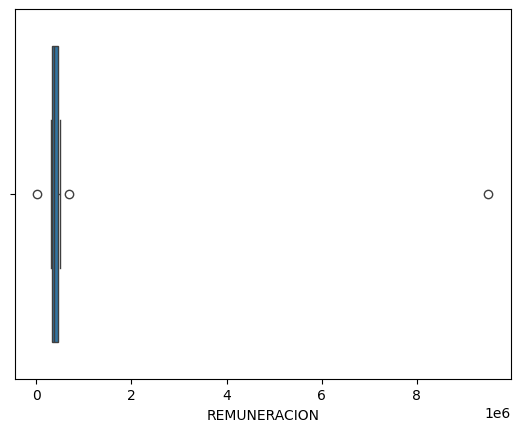

In [ ]:
# 3.4. Visualización de Outliers
print("Visualización de Outliers en REMUNERACION")
sns.boxplot(x=df_empleados_limpio['REMUNERACION'])
plt.show()

In [ ]:
# 2. Calcular el Rango Intercuartílico (IQR) y los límites
Q1 = df_empleados_limpio['REMUNERACION'].quantile(0.25)
Q3 = df_empleados_limpio['REMUNERACION'].quantile(0.75)
IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

print(f"\nQ1: {Q1}, Q3: {Q3}, IQR: {IQR}")
print(f"Límite inferior: {limite_inferior}, Límite superior: {limite_superior}")

# 3. Identificar los outliers
outliers_mask = (df_empleados_limpio['REMUNERACION'] < limite_inferior) | (df_empleados_limpio['REMUNERACION'] > limite_superior)
print("Posibles outliers:")
print(outliers_mask)


Q1: 327500.0, Q3: 465000.0, IQR: 137500.0
Límite inferior: 121250.0, Límite superior: 671250.0
Posibles outliers:
0     False
1     False
3     False
4     False
5     False
6      True
7     False
8      True
10     True
11    False
12    False
13    False
Name: REMUNERACION, dtype: bool



Boxplot de REMUNERACION después de corregir outliers


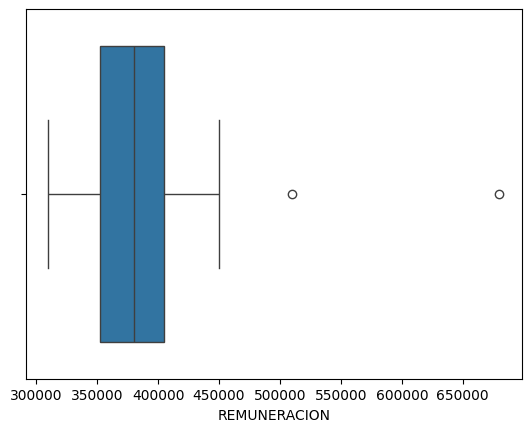

In [ ]:
# Corregimos los outliers reemplazándolos por la mediana
# Podríamos usar límites más formales como el Rango Intercuartílico (IQR),
# pero para este caso, los identificamos visualmente.
df_empleados_limpio.loc[df_empleados_limpio['REMUNERACION'] > 2000000, 'REMUNERACION'] = mediana_remuneracion
df_empleados_limpio.loc[df_empleados_limpio['REMUNERACION'] < 100000, 'REMUNERACION'] = mediana_remuneracion

print("\nBoxplot de REMUNERACION después de corregir outliers")
sns.boxplot(x=df_empleados_limpio['REMUNERACION'])
plt.show()

In [ ]:
# Paso 4: Verificación Final
print("--- Información Final del DataFrame Limpio ---")
df_empleados_limpio.info()

print("\n--- Muestra del DataFrame Final Limpio ---")
display(df_empleados_limpio.head(12))

--- Información Final del DataFrame Limpio ---
<class 'pandas.core.frame.DataFrame'>
Index: 12 entries, 0 to 13
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NOMBRE        12 non-null     object 
 1   DNI           12 non-null     object 
 2   AREA          12 non-null     object 
 3   PUESTO        12 non-null     object 
 4   REMUNERACION  12 non-null     float64
dtypes: float64(1), object(4)
memory usage: 576.0+ bytes

--- Muestra del DataFrame Final Limpio ---


,NOMBRE,DNI,AREA,PUESTO,REMUNERACION
0,Ana Gómez,35.123.456,Ventas,Vendedor Sr.,450000.0
1,Carlos Diaz,38.789.123,Tecnología,Desarrollador Jr.,380000.0
3,Laura Fernandez,40.456.789,Marketing,Administrativo,320000.0
4,Pedro Martinez,33.987.654,Administración,Analista de Datos,510000.0
5,Sofia Rodriguez,41.111.222,Ventas,Vendedor Jr.,380000.0
6,Martin Lopez,29.555.888,Gerencia,Gerente de Área,380000.0
7,Valentina Torres,42.333.444,RRHH,Analista de RRHH,390000.0
8,Javier Moreno,37.666.777,Tecnología,Desarrollador Sr.,680000.0
10,Lucia Gimenez,43.222.111,Administración,Asistente,380000.0
11,Mateo Acosta,39.888.999,Marketing,Administrativo,330000.0


        REMUNERACION
count      12.000000
mean   405833.333333
std    102377.051169
min    310000.000000
25%    352500.000000
50%    380000.000000
75%    405000.000000
max    680000.000000


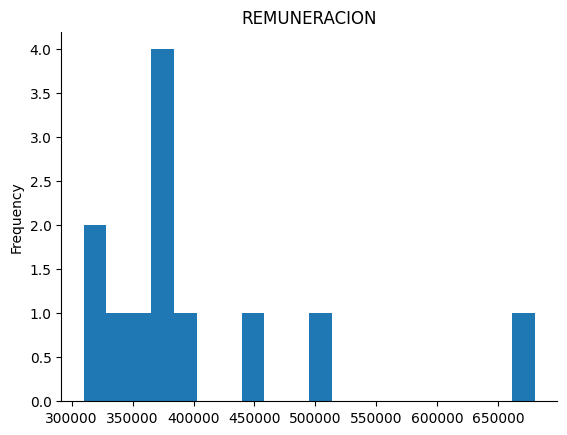

In [ ]:
from matplotlib import pyplot as plt
df_empleados_limpio['REMUNERACION'].plot(kind='hist', bins=20, title='REMUNERACION')
plt.gca().spines[['top', 'right',]].set_visible(False)
print(df_empleados_limpio.describe())

In [ ]:
# Continuando df_empleados_limpio que es DataFrame de la clase anterior
# y una tasa de cambio de 1 USD = 1300 ARS

df_empleados_limpio['REMUNERACION_USD'] = df_empleados_limpio['REMUNERACION'].apply(lambda x: round(x / 1300, 2))

print("DataFrame con la nueva columna de remuneración en USD:")
print(df_empleados_limpio[['NOMBRE', 'REMUNERACION', 'REMUNERACION_USD']].head(13))

DataFrame con la nueva columna de remuneración en USD:
              NOMBRE  REMUNERACION  REMUNERACION_USD
0          Ana Gómez      450000.0            346.15
1        Carlos Diaz      380000.0            292.31
3    Laura Fernandez      320000.0            246.15
4     Pedro Martinez      510000.0            392.31
5    Sofia Rodriguez      380000.0            292.31
6       Martin Lopez      380000.0            292.31
7   Valentina Torres      390000.0            300.00
8      Javier Moreno      680000.0            523.08
10     Lucia Gimenez      380000.0            292.31
11      Mateo Acosta      330000.0            253.85
12       Daniel Sosa      360000.0            276.92
13       Camila Ruiz      310000.0            238.46


In [ ]:
# Agrupación por 'AREA' y aplicamos múltiples funciones de agregación
resumen_por_area = df_empleados_limpio.groupby('AREA').agg(
    Cantidad_Empleados=('DNI', 'count'),
    Salario_Promedio=('REMUNERACION', 'mean')
).round(2)

print("Resumen de empleados y salarios por área:")
print(resumen_por_area)

Resumen de empleados y salarios por área:
                Cantidad_Empleados  Salario_Promedio
AREA                                                
Administración                   4          390000.0
Gerencia                         1          380000.0
Marketing                        2          325000.0
RRHH                             1          390000.0
Tecnología                       2          530000.0
Ventas                           2          415000.0


In [ ]:
df_evaluaciones = pd.read_csv("/content/Desemp.csv")


# Usamos pd.merge() para combinar los DataFrames. Un 'left' join mantiene todos los empleados
# de la tabla original y agrega la evaluación si existe.
df_completo = pd.merge(df_empleados_limpio, df_evaluaciones, on='DNI', how='inner')

print("DataFrame combinado con la evaluación de desempeño:")
print(df_completo[['NOMBRE', 'AREA', 'Eval_Des']].head())

DataFrame combinado con la evaluación de desempeño:
            NOMBRE            AREA   Eval_Des
0        Ana Gómez          Ventas      Bueno
1      Carlos Diaz      Tecnología  Muy Bueno
2  Laura Fernandez       Marketing  Muy Bueno
3   Pedro Martinez  Administración  Muy Bueno
4  Sofia Rodriguez          Ventas    Regular
